In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [3]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "mathtext.fontset": "dejavuserif",  # or "cm" for Computer Modern
    "mathtext.rm": "serif",
    "mathtext.it": "serif:italic",
    "mathtext.bf": "serif:bold",
})

In [4]:
data = {
    'BPASS': [
        ['fiducial', 4701303, 11649, 1738], ['m2_min_05', -100, 0, -100], ['porb_log_uniform', -100, 0, -100],
        ['qmin_01', -100, 0, -100], ['thermal_ecc', -100, 0, -100], ['uniform_ecc', -100, 0, -100],
        ['accretion_1', -100, 0, -100], ['accretion_05', -100, 0, -100], ['accretion_0', -100, 0, -100],
        ['alpha_lambda_02', -100, 0, -100], ['alpha_lambda_05', -100, 0, -100], ['alpha_lambda_1', -100, 0, -100],
        ['alpha_lambda_2', -100, 0, -100], ['alpha_gamma_2', -100, 0, -100], ['qcrit_claeys_14', -100, 0, -100],
        ['qcrit_hurley_02', -100, 0, -100], ['qcrit_hurley_webbink', -100, 0, -100], ['qcrit_zetas', -100, 0, -100]
    ],
    'BSE': [
        ['fiducial', 682750, 1801, 2069], ['m2_min_05', 899223, 2418, 3854], ['porb_log_uniform', 1473277, 3833, 5112],
        ['qmin_01', 768608, 2030, 2259], ['thermal_ecc', 1174352, 3107, 3098], ['uniform_ecc', 895952, 2302, 2816],
        ['accretion_1', 1646500, 4425, 2340], ['accretion_05', 1888477, 5442, 5156], ['accretion_0', 5871070, 18035, 7259],
        ['alpha_lambda_02', 15935095, 49048, 21273], ['alpha_lambda_05', 5221683, 13545, 4521], ['alpha_lambda_1', 2088015, 5466, 5733],
        ['alpha_lambda_2', 3709157, 12744, 11514], ['alpha_gamma_2', -100, 0, -100], ['qcrit_claeys_14', 10496869, 29622, 20243],
        ['qcrit_hurley_02', 10410303, 28794, 20175], ['qcrit_hurley_webbink', 9901285, 27327, 19954], ['qcrit_zetas', -100, 0, -100]
    ],
    'ComBinE': [
        ['fiducial', 1380066, 4123, 1050], ['m2_min_05', 1774359, 5220, 1868], ['porb_log_uniform', 6563600, 20255, 3291],
        ['qmin_01', 1512989, 4560, 1082], ['thermal_ecc', 3159948, 9593, 1899], ['uniform_ecc', 2383029, 7501, 1533],
        ['accretion_1', -100, 0, -100], ['accretion_05', -100, 0, -100], ['accretion_0', -100, 0, -100],
        ['alpha_lambda_02', -100, 0, -100], ['alpha_lambda_05', -100, 0, -100], ['alpha_lambda_1', -100, 0, -100],
        ['alpha_lambda_2', -100, 0, -100], ['alpha_gamma_2', -100, 0, -100], ['qcrit_claeys_14', -100, 0, -100],
        ['qcrit_hurley_02', -100, 0, -100], ['qcrit_hurley_webbink', -100, 0, -100], ['qcrit_zetas', -100, 0, -100]
    ],
    'COMPAS': [
        ['fiducial', 9050421, 28038, 24131], ['m2_min_05', 10045508, 30096, 27273], ['porb_log_uniform', 20845392, 64078, 46483],
        ['qmin_01', 9506515, 27435, 23049], ['thermal_ecc', 14463713, 44403, 34524], ['uniform_ecc', 12772570, 36912, 30549],
        ['accretion_1', 13404085, 40373, 34159], ['accretion_05', 14044288, 41205, 32628], ['accretion_0', 8878804, 27293, 23048],
        ['alpha_lambda_02', 917881, 2693, 1879], ['alpha_lambda_05', 1271352, 4459, 5168], ['alpha_lambda_1', 4002517, 12095, 18580],
        ['alpha_lambda_2', 12346363, 37187, 21618], ['alpha_gamma_2', -100, 0, -100], ['qcrit_claeys_14', 15551985, 46496, 35150],
        ['qcrit_hurley_02', -100, 0, -100], ['qcrit_hurley_webbink', 15107409, 45473, 34795], ['qcrit_zetas', 9050421, 28219, 24271]
    
    ],
    'COSMIC': [
        ['fiducial', 10577427, 29849, 21488], ['m2_min_05', 13562610, 36998, 22477], ['porb_log_uniform', 13158246, 37211, 28235],
        ['qmin_01', 6000144, 16272, 10690], ['thermal_ecc', 12634161, 35501, 34269], ['uniform_ecc', 11904131, 33426, 27996],
        ['accretion_1', 10377039, 29138, 22244], ['accretion_05', 11640795, 33804, 24995], ['accretion_0', 14370007, 41989, 24985],
        ['alpha_lambda_02', 455548, 1322, 902], ['alpha_lambda_05', 2752021, 7848, 15230], ['alpha_lambda_1', 6904546, 20009, 13949],
        ['alpha_lambda_2', 15819071, 47172, 25379], ['alpha_gamma_2', -100, 0, -100], ['qcrit_claeys_14', -100, 0, -100],
        ['qcrit_hurley_02', 10432511, 31339, 22395], ['qcrit_hurley_webbink', 10072705, 28405, 21809], ['qcrit_zetas', -100, 0, -100]
    ],
    'METISSE': [
        ['fiducial', 897184, 2201, 10240], ['m2_min_05', 1430626, 3402, 15476], ['porb_log_uniform', 4517786, 11502, 13655],
        ['qmin_01', 5045770, 13845, 10544], ['thermal_ecc', 1212576, 3031, 15459], ['uniform_ecc', 1145000, 2777, 17528],
        ['accretion_1', 4532259, 12110, 13475], ['accretion_05', 6354516, 17779, 18446], ['accretion_0', 6354516, 17792, 18635],
        ['alpha_lambda_02', 223659, 789, 344], ['alpha_lambda_05', 523150, 1389, 1943], ['alpha_lambda_1', 3037939, 7868, 6351],
        ['alpha_lambda_2', 11359315, 32442, 16283], ['alpha_gamma_2', -100, 0, -100], ['qcrit_claeys_14', -100, 0, -100],
        ['qcrit_hurley_02', 4522314, 11468, 13691], ['qcrit_hurley_webbink', 4115584, 10840, 13552], ['qcrit_zetas', -100, 0, -100]
    ],
    'SeBa': [
        ['fiducial', 12961133, 40594, 19964], ['m2_min_05', 15714131, 46293, 18142], ['porb_log_uniform', 38020147, 110410, 46320],
        ['qmin_01', 14012876, 41534, 17216], ['thermal_ecc', 13401368, 39694, 15010], ['uniform_ecc', 12988395, 37458, 17774],
        ['accretion_1', 16404253, 48326, 28178], ['accretion_05', 13110956, 38887, 23283], ['accretion_0', 10156149, 30529, 16936],
        ['alpha_lambda_02', 6901, 28, 434], ['alpha_lambda_05', 1037327, 2923, 10216], ['alpha_lambda_1', 4930764, 14052, 25990],
        ['alpha_lambda_2', -100, 0, -100], ['alpha_gamma_2', 9593505, 28358, 17813], ['qcrit_claeys_14', -100, 0, -100],
        ['qcrit_hurley_02', -100, 0, -100], ['qcrit_hurley_webbink', -100, 0, -100], ['qcrit_zetas', -100, 0, -100]
    ],
    'SEVN': [
        ['fiducial', 9224236, 26842, 24068], ['m2_min_05', 11727026, 32319, 32228], ['porb_log_uniform', 13699038, 41864, 63134],
        ['qmin_01', 9714276, 29609, 30434], ['thermal_ecc', 11632126, 33011, 32566], ['uniform_ecc', 11046966, 32721, 32809],
        ['accretion_1', 10225639, 31004, 21828], ['accretion_05', 9224236, 27027, 23967], ['accretion_0', 13937562, 41060, 25835],
        ['alpha_lambda_02', 1052160, 3545, 1348], ['alpha_lambda_05', 1632843, 4931, 11370], ['alpha_lambda_1', 6115259, 17293, 26970],
        ['alpha_lambda_2', 12682517, 36779, 38524], ['alpha_gamma_2', -100, 0, -100], ['qcrit_claeys_14', 9427305, 27339, 24443],
        ['qcrit_hurley_02', 8512210, 23817, 22904], ['qcrit_hurley_webbink', 8280176, 24674, 22880], ['qcrit_zetas', -100, 0, -100]
    ]
}

In [5]:
columns = ["variation", "N_tot_f_gt_1e-4", "N_1kpc_f_gt_1e-4", "N_LISA_det"]

all_rows = []
for code, rows in data.items():
    for row in rows:
        all_rows.append([code] + row)

full_df = pd.DataFrame(all_rows, columns=["code"] + columns)

In [6]:
full_df

,code,variation,N_tot_f_gt_1e-4,N_1kpc_f_gt_1e-4,N_LISA_det
0,BPASS,fiducial,4701303,11649,1738
1,BPASS,m2_min_05,-100,0,-100
2,BPASS,porb_log_uniform,-100,0,-100
3,BPASS,qmin_01,-100,0,-100
4,BPASS,thermal_ecc,-100,0,-100
...,...,...,...,...,...
139,SEVN,alpha_gamma_2,-100,0,-100
140,SEVN,qcrit_claeys_14,9427305,27339,24443
141,SEVN,qcrit_hurley_02,8512210,23817,22904
142,SEVN,qcrit_hurley_webbink,8280176,24674,22880


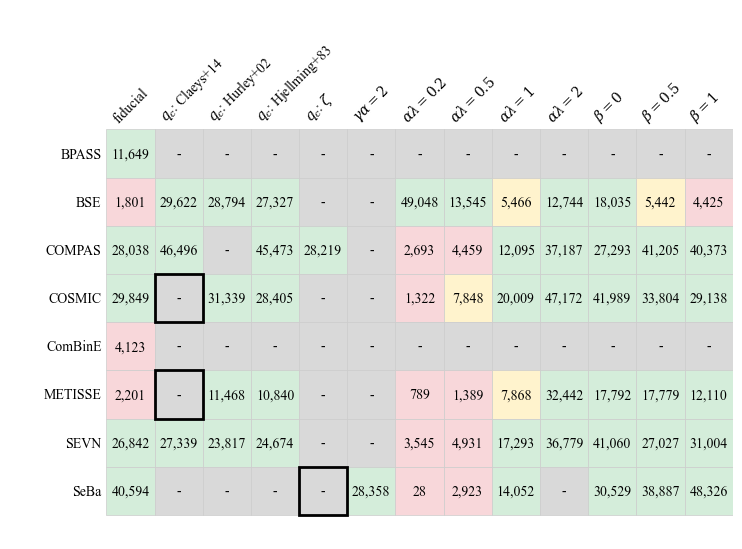

In [7]:
# Grid figure: rows = code, columns = variation, values = N_1kpc_f_gt_1e-4
pivot = full_df.pivot(index="code", columns="variation", values="N_1kpc_f_gt_1e-4")

# Replace -100 sentinel with NaN for display
pivot_display = pivot.replace(-100, float('nan'))

var_order = [
    'fiducial', 'qcrit_claeys_14', 'qcrit_hurley_02', 'qcrit_hurley_webbink', 'qcrit_zetas',
    'alpha_gamma_2', 'alpha_lambda_02', 'alpha_lambda_05', 'alpha_lambda_1', 'alpha_lambda_2',
    'accretion_0', 'accretion_05', 'accretion_1'
]

label_map = {
    'fiducial': 'fiducial',
    'qcrit_claeys_14': r'$q_c$: Claeys+14',
    'qcrit_hurley_02': r'$q_c$: Hurley+02',
    'qcrit_hurley_webbink': r'$q_c$: Hjellming+83',
    'qcrit_zetas': r'$q_c$: $\zeta$',
    'alpha_gamma_2': r'$\gamma \alpha = 2$',
    'alpha_lambda_02': r'$\alpha \lambda = 0.2$',
    'alpha_lambda_05': r'$\alpha \lambda = 0.5$',
    'alpha_lambda_1': r'$\alpha \lambda = 1$',
    'alpha_lambda_2': r'$\alpha \lambda = 2$',
    'accretion_0': r'$\beta = 0$',
    'accretion_05': r'$\beta = 0.5$',
    'accretion_1': r'$\beta = 1$'
}

var_order = [v for v in var_order if v in pivot_display.columns]
var_labels = [label_map[v] for v in var_order]
pivot_display = pivot_display[var_order]

codes = pivot_display.index.tolist()
variations = pivot_display.columns.tolist()

highlight_cells = {
    ("COSMIC", "qcrit_claeys_14"),
    ("METISSE", "qcrit_claeys_14"),
    ("SeBa", "qcrit_zetas"),
}

fig, ax = plt.subplots(figsize=(len(variations) * 1.3, len(codes) * 0.7))
ax.set_xlim(0, len(variations))
ax.set_ylim(0, len(codes))
ax.set_aspect('equal')
ax.axis('off')

# Draw cells
for i, code in enumerate(codes):
    for j, var in enumerate(variations):
        val = pivot_display.loc[code, var]
        if pd.isna(val):
            text = "—"
        elif val == 0:
            text = "-"
        else:
            text = f"{int(val):,}"
        # Value-based coloring
        if pd.isna(val):
            color = "white"
        elif val == 0:
            color = "#d9d9d9"   # light grey
        elif val < 5000:
            color = "#f8d7da"   # light red
        elif val < 10000:
            color = "#fff3cd"   # light yellow
        else:
            color = "#d4edda"   # light green

        rect = plt.Rectangle([j, len(codes) - i - 1], 1, 1, facecolor=color, edgecolor='#cccccc', linewidth=0.5)
        # Add black outline for selected cells
        if (code, var) in highlight_cells:
            outline = plt.Rectangle(
                [j, len(codes) - i - 1], 1, 1,
                fill=False, edgecolor="black", linewidth=2.0,
                zorder=10)
            ax.add_patch(outline)
        ax.add_patch(rect)
        ax.text(j + 0.5, len(codes) - i - 0.5, text, ha='center', va='center', fontsize=10,
                color='black' if not pd.isna(val) else '#aaaaaa')

# Column headers (variations)
for j, label in enumerate(var_labels):
    ax.text(
        j + 0.3,            # left edge of block (+ small padding)
        len(codes) + 0.1,
        label,
        ha="left",           # start text at anchor x
        va="bottom",
        fontsize=10,
        rotation=45,
        rotation_mode="anchor"
    )

# Row headers (codes)
for i, code in enumerate(codes):
    ax.text(-0.1, len(codes) - i - 0.5, code, ha='right', va='center', fontsize=10)

# Legend
legend_handles = [
    Patch(facecolor="#d9d9d9", edgecolor="#cccccc", label="0"),
    Patch(facecolor="#f8d7da", edgecolor="#cccccc", label="< 5,000"),
    Patch(facecolor="#fff3cd", edgecolor="#cccccc", label="5,000-9,999"),
    Patch(facecolor="#d4edda", edgecolor="#cccccc", label=">= 10,000"),
]



ax.set_xlim(-2, len(variations))
ax.set_ylim(-0.5, len(codes) + 2.5)
plt.tight_layout()
plt.savefig("N_1kpc_grid.pdf", bbox_inches='tight')
plt.show()

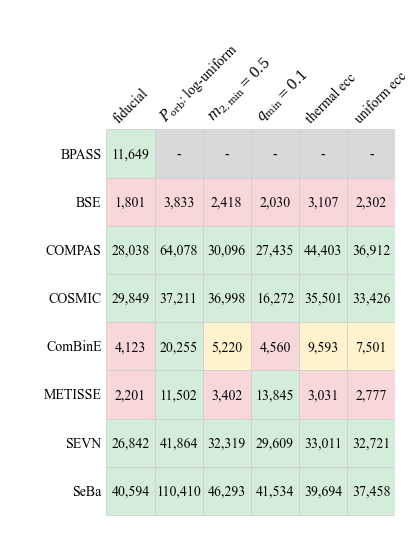

In [8]:
# Grid figure: rows = code, columns = variation, values = N_1kpc_f_gt_1e-4
pivot = full_df.pivot(index="code", columns="variation", values="N_1kpc_f_gt_1e-4")

# Replace -100 sentinel with NaN for display
pivot_display = pivot.replace(-100, float('nan'))


var_order = [
    "fiducial",
    "porb_log_uniform",
    "m2_min_05",
    "qmin_01",
    "thermal_ecc",
    "uniform_ecc",
]

label_map = {
    "fiducial": "fiducial",
    "porb_log_uniform": r"$P_{\mathrm{orb}}$: log-uniform",
    "m2_min_05": r"$m_{2,\min}=0.5$",
    "qmin_01": r"$q_{\min}=0.1$",
    "thermal_ecc": "thermal ecc",
    "uniform_ecc": "uniform ecc",
}

var_order = [v for v in var_order if v in pivot_display.columns]
var_labels = [label_map[v] for v in var_order]
pivot_display = pivot_display[var_order]

codes = pivot_display.index.tolist()
variations = pivot_display.columns.tolist()


fig, ax = plt.subplots(figsize=(len(variations) * 1.3, len(codes) * 0.7))
ax.set_xlim(0, len(variations))
ax.set_ylim(0, len(codes))
ax.set_aspect('equal')
ax.axis('off')

# Draw cells
for i, code in enumerate(codes):
    for j, var in enumerate(variations):
        val = pivot_display.loc[code, var]
        if pd.isna(val):
            text = "—"
        elif val == 0:
            text = "-"
        else:
            text = f"{int(val):,}"
        # Value-based coloring
        if pd.isna(val):
            color = "white"
        elif val == 0:
            color = "#d9d9d9"   # light grey
        elif val < 5000:
            color = "#f8d7da"   # light red
        elif val < 10000:
            color = "#fff3cd"   # light yellow
        else:
            color = "#d4edda"   # light green

        rect = plt.Rectangle([j, len(codes) - i - 1], 1, 1, facecolor=color, edgecolor='#cccccc', linewidth=0.5)
        
        ax.add_patch(rect)
        ax.text(j + 0.5, len(codes) - i - 0.5, text, ha='center', va='center', fontsize=10,
                color='black' if not pd.isna(val) else '#aaaaaa')

# Column headers (variations)
for j, label in enumerate(var_labels):
    ax.text(
        j + 0.3,            # left edge of block (+ small padding)
        len(codes) + 0.1,
        label,
        ha="left",           # start text at anchor x
        va="bottom",
        fontsize=10,
        rotation=45,
        rotation_mode="anchor"
    )

# Row headers (codes)
for i, code in enumerate(codes):
    ax.text(-0.1, len(codes) - i - 0.5, code, ha='right', va='center', fontsize=10)

# Legend
legend_handles = [
    Patch(facecolor="#d9d9d9", edgecolor="#cccccc", label="0"),
    Patch(facecolor="#f8d7da", edgecolor="#cccccc", label="< 5,000"),
    Patch(facecolor="#fff3cd", edgecolor="#cccccc", label="5,000-9,999"),
    Patch(facecolor="#d4edda", edgecolor="#cccccc", label=">= 10,000"),
]



ax.set_xlim(-2, len(variations))
ax.set_ylim(-0.5, len(codes) + 2.5)
plt.tight_layout()
plt.savefig("N_1kpc_grid_ic_variations.pdf", bbox_inches='tight')
plt.show()

In [9]:
channel_counts = pd.read_hdf('channel_count_summary.hdf5', key='counts')

In [89]:
print(channel_counts.columns)
channel_counts.phase.value_counts()

Index(['code', 'variation', 'phase', 'channel_id', 'count', 'count_k'], dtype='object')


phase
ZAMS        582
WDMS        582
DWD         582
LISA_DWD    582
Galaxy      582
Name: count, dtype: int64

In [13]:
channel_counts.variation.unique()

array(['fiducial', 'm2_min_05', 'porb_log_uniform', 'qmin_01',
       'thermal_ecc', 'uniform_ecc', 'accretion_1', 'accretion_05',
       'accretion_0', 'alpha_lambda_02', 'alpha_lambda_05',
       'alpha_lambda_1', 'alpha_lambda_2', 'qcrit_claeys_14',
       'qcrit_hurley_02', 'qcrit_hurley_webbink', 'qcrit_zetas',
       'alpha_gamma_2'], dtype=object)

In [42]:
mt_vars = ['fiducial','accretion_0','accretion_05', 'accretion_1', 'alpha_lambda_02', 'alpha_lambda_05',
       'alpha_lambda_1', 'alpha_lambda_2', 'alpha_gamma_2', 'qcrit_claeys_14',
       'qcrit_hurley_02', 'qcrit_hurley_webbink', 'qcrit_zetas']

ic_vars = ['fiducial', 'm2_min_05', 'porb_log_uniform', 'qmin_01', 'thermal_ecc', 'uniform_ecc']

/Users/kbreivik/miniforge3/envs/cosmic/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


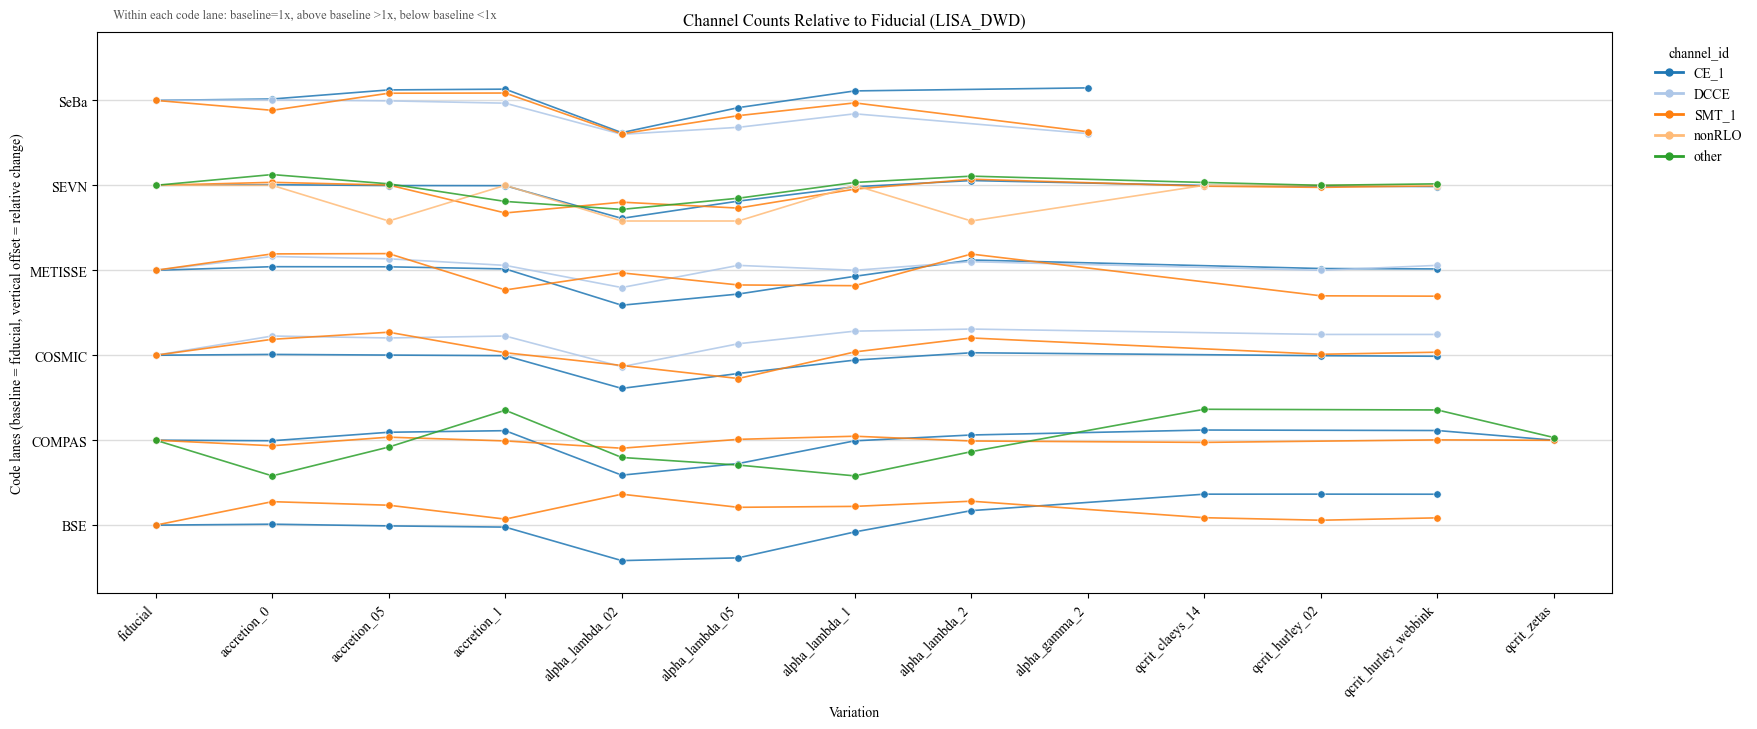

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------------
# Settings
# ----------------------------
phase_to_plot = "LISA_DWD"   # change if needed, e.g. "DWD", "WDMS", "ZAMS", "Galaxy"
annotate_points = False      # True will write "1.2x" etc on each point
lane_span = 0.42             # max up/down offset inside each code lane

# User-defined mt_vars already in your notebook:
# mt_vars = [...]

# ----------------------------
# Prepare data
# ----------------------------
df = channel_counts.copy()

required = {"code", "variation", "channel_id"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Pick numeric count column
if "count" in df.columns:
    count_col = "count"
else:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in ["ID"]]
    if not numeric_cols:
        raise ValueError("No numeric count column found. Expected e.g. 'count'.")
    count_col = numeric_cols[0]
    print(f"Using numeric column '{count_col}' as count.")

# Optional phase filter
if "phase" in df.columns:
    if phase_to_plot not in df["phase"].astype(str).unique():
        print(f"Phase '{phase_to_plot}' not found. Using all phases.")
    else:
        df = df[df["phase"] == phase_to_plot].copy()

# Keep only requested MT variations
df = df[df["variation"].isin(mt_vars)].copy()

# If there are duplicate rows per combo, sum them
df = (
    df.groupby(["code", "variation", "channel_id"], as_index=False)[count_col]
      .sum()
)

# Fiducial normalization by (code, channel_id)
fid = (
    df[df["variation"] == "fiducial"][["code", "channel_id", count_col]]
    .rename(columns={count_col: "fiducial_count"})
)

plot_df = df.merge(fid, on=["code", "channel_id"], how="left")
# Remove merger-like channels (case-insensitive)
plot_df = plot_df[
    ~plot_df["channel_id"].astype(str).str.contains("merger", case=False, na=False)
].copy()

# Relative-to-fiducial
plot_df["rel"] = np.where(
    (plot_df["fiducial_count"] > 0) & np.isfinite(plot_df["fiducial_count"]),
    plot_df[count_col] / plot_df["fiducial_count"],
    np.nan
)

# Drop rows where fiducial doesn't exist or is zero
plot_df = plot_df.dropna(subset=["rel"]).copy()

# Order
var_order = [v for v in mt_vars if v in plot_df["variation"].unique()]
code_order = sorted([c for c in plot_df["code"].unique().tolist() if c != "ComBinE"])
chan_order = sorted(plot_df["channel_id"].astype(str).unique().tolist())


plot_df["variation"] = pd.Categorical(plot_df["variation"], categories=var_order, ordered=True)
plot_df["x"] = plot_df["variation"].cat.codes

# Stagger transform:
# rel=1 -> baseline of code lane
# rel>1 -> above baseline, rel<1 -> below baseline
# tanh(log2(rel)/3) keeps extreme ratios from exploding visually
plot_df["delta"] = lane_span * np.tanh(np.log2(plot_df["rel"]) / 3.0)

code_to_y = {c: i for i, c in enumerate(code_order)}
plot_df["y_base"] = plot_df["code"].map(code_to_y)
plot_df["y"] = plot_df["y_base"] + plot_df["delta"]

# ----------------------------
# Plot
# ----------------------------
fig_w = max(12, 1.05 * len(var_order) + 4)
fig_h = max(6, 0.9 * len(code_order) + 2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# Color map for channels
cmap = plt.get_cmap("tab20")
chan_to_color = {ch: cmap(i % 20) for i, ch in enumerate(chan_order)}

# Baseline lane for each code
for code, y0 in code_to_y.items():
    ax.axhline(y0, color="#dddddd", lw=1.0, zorder=0)

# Draw lines per (code, channel)
for code in code_order:
    d_code = plot_df[plot_df["code"] == code]
    for ch in chan_order:
        s = d_code[d_code["channel_id"].astype(str) == ch].sort_values("x")
        if s.empty:
            continue

        ax.plot(
            s["x"], s["y"],
            color=chan_to_color[ch],
            lw=1.2,
            alpha=0.85,
            zorder=2
        )
        ax.scatter(
            s["x"], s["y"],
            color=chan_to_color[ch],
            s=28,
            alpha=0.95,
            edgecolor="white",
            linewidth=0.4,
            zorder=3
        )

        if annotate_points:
            for _, r in s.iterrows():
                ax.text(
                    r["x"], r["y"] + 0.015,
                    f"{r['rel']:.2g}x",
                    fontsize=7,
                    ha="center",
                    va="bottom",
                    color=chan_to_color[ch],
                    alpha=0.9
                )

# Axes formatting
ax.set_xticks(range(len(var_order)))
ax.set_xticklabels(var_order, rotation=45, ha="right")
ax.set_yticks([code_to_y[c] for c in code_order])
ax.set_yticklabels(code_order)

ax.set_xlim(-0.5, len(var_order) - 0.5)
ax.set_ylim(-0.8, len(code_order) - 0.2)

title_phase = phase_to_plot if ("phase" in channel_counts.columns and phase_to_plot in channel_counts["phase"].astype(str).unique()) else "all phases"
ax.set_title(f"Channel Counts Relative to Fiducial ({title_phase})")
ax.set_xlabel("Variation")
ax.set_ylabel("Code lanes (baseline = fiducial, vertical offset = relative change)")

# Small guide text
ax.text(
    0.01, 1.02,
    "Within each code lane: baseline=1x, above baseline >1x, below baseline <1x",
    transform=ax.transAxes,
    fontsize=9,
    ha="left",
    va="bottom",
    color="#555555"
)

# Channel legend
legend_handles = [
    Line2D([0], [0], color=chan_to_color[ch], marker='o', lw=2, label=str(ch), markersize=5)
    for ch in chan_order
]
ax.legend(
    handles=legend_handles,
    title="channel_id",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    ncol=1
)

plt.tight_layout()
plt.show()

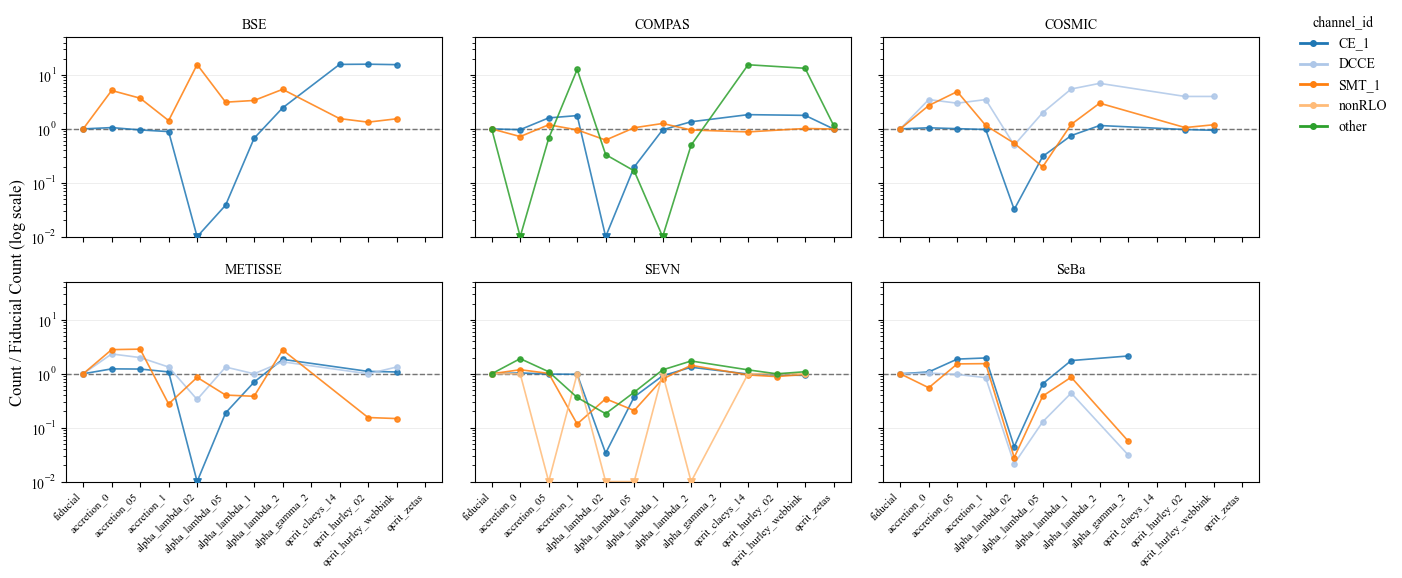

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

# ----------------------------
# Settings
# ----------------------------
phase_to_plot = "LISA_DWD"   # set None to include all phases
ncols = 3
y_fixed = (0.01, 50.0)        # fixed relative range for all panels
save_fig = False
outname = "channel_relative_mt_panels_fixed_ylim.pdf"

# ----------------------------
# Prepare data
# ----------------------------
df = channel_counts.copy()

required = {"code", "variation", "channel_id"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if "count" in df.columns:
    count_col = "count"
else:
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "ID"]
    if not numeric_cols:
        raise ValueError("No numeric count column found.")
    count_col = numeric_cols[0]
    print(f"Using '{count_col}' as count column.")

if phase_to_plot is not None and "phase" in df.columns:
    if phase_to_plot in df["phase"].astype(str).unique():
        df = df[df["phase"] == phase_to_plot].copy()
    else:
        print(f"Phase '{phase_to_plot}' not found; using all phases.")

df = df[df["variation"].isin(mt_vars)].copy()

# collapse duplicates per code-variation-channel
df = df.groupby(["code", "variation", "channel_id"], as_index=False)[count_col].sum()

# fiducial baseline per code+channel
fid = (
    df[df["variation"] == "fiducial"][["code", "channel_id", count_col]]
    .rename(columns={count_col: "fiducial_count"})
)

plot_df = df.merge(fid, on=["code", "channel_id"], how="left")
# Remove merger-like channels (case-insensitive)
plot_df = plot_df[
    ~plot_df["channel_id"].astype(str).str.contains("merger", case=False, na=False)
].copy()


plot_df["rel"] = np.where(
    (plot_df["fiducial_count"] > 0) & np.isfinite(plot_df["fiducial_count"]),
    plot_df[count_col] / plot_df["fiducial_count"],
    np.nan
)
plot_df = plot_df.dropna(subset=["rel"]).copy()

var_order = [v for v in mt_vars if v in plot_df["variation"].unique()]
code_order = sorted([c for c in plot_df["code"].unique().tolist() if c != "ComBinE"])
chan_order = sorted(plot_df["channel_id"].astype(str).unique().tolist())

plot_df["variation"] = pd.Categorical(plot_df["variation"], categories=var_order, ordered=True)
plot_df["x"] = plot_df["variation"].cat.codes

# channel colors (shared across panels)
cmap = plt.get_cmap("tab20")
chan_to_color = {ch: cmap(i % 20) for i, ch in enumerate(chan_order)}

# ----------------------------
# Plot
# ----------------------------
n_codes = len(code_order)
nrows = math.ceil(n_codes / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4.3 * ncols, 2.9 * nrows),
    sharex=True,
    sharey=True
)
axes = np.atleast_1d(axes).ravel()

for i, code in enumerate(code_order):
    ax = axes[i]
    d_code = plot_df[plot_df["code"] == code]

    ax.axhline(1.0, color="#666666", lw=1.0, ls="--", zorder=0)

    for ch in chan_order:
        s = d_code[d_code["channel_id"].astype(str) == ch].sort_values("x")
        if s.empty:
            continue

        y = s["rel"].values

        # clip for display while preserving trend when values exceed fixed limits
        y_plot = np.clip(y, y_fixed[0], y_fixed[1])

        ax.plot(
            s["x"].values, y_plot,
            color=chan_to_color[ch],
            lw=1.2, alpha=0.85,
            marker="o", markersize=3.8
        )

        # mark clipped points
        hi = y > y_fixed[1]
        lo = y < y_fixed[0]
        if hi.any():
            ax.scatter(
                s["x"].values[hi], np.full(hi.sum(), y_fixed[1]),
                marker="^", s=28, color=chan_to_color[ch], zorder=4
            )
        if lo.any():
            ax.scatter(
                s["x"].values[lo], np.full(lo.sum(), y_fixed[0]),
                marker="v", s=28, color=chan_to_color[ch], zorder=4
            )

    ax.set_title(code, fontsize=10)
    ax.set_yscale("log")
    ax.set_ylim(*y_fixed)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)

    ax.set_xticks(range(len(var_order)))
    ax.set_xticklabels(var_order, rotation=45, ha="right", fontsize=8)

# hide unused panels
for j in range(n_codes, len(axes)):
    axes[j].set_visible(False)

#fig.suptitle(
#    "Relative Channel Counts by MT Variation"
#    + (f" ({phase_to_plot})" if phase_to_plot is not None else ""),
#    y=1.02, fontsize=12#
#)
#fig.supxlabel("Variation")
fig.supylabel("Count / Fiducial Count (log scale)")

legend_handles = [
    Line2D([0], [0], color=chan_to_color[ch], lw=2, marker="o", markersize=4, label=str(ch))
    for ch in chan_order
]
fig.legend(
    handles=legend_handles,
    title="channel_id",
    bbox_to_anchor=(1.01, 1.0),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
if save_fig:
    plt.savefig(outname, bbox_inches="tight")
plt.show()

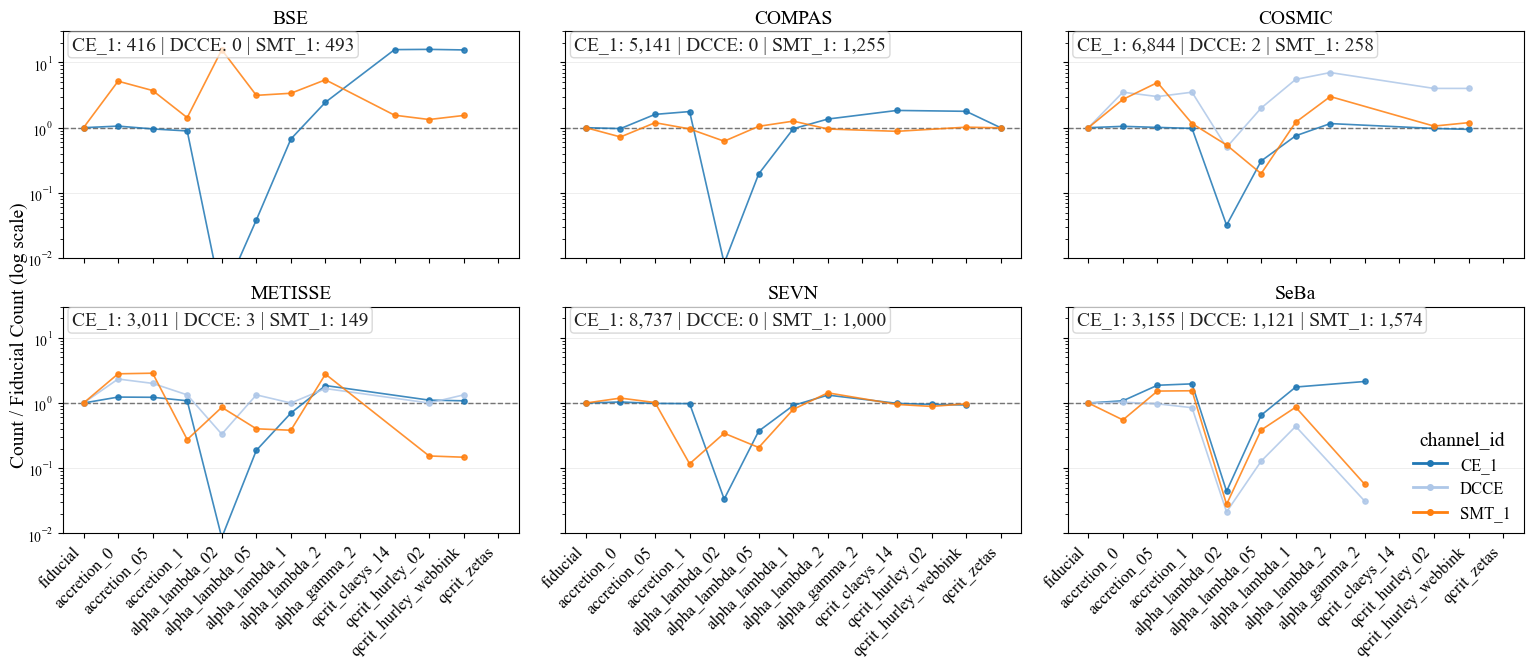

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

# ----------------------------
# Settings
# ----------------------------
phase_to_plot = "LISA_DWD"   # set None to include all phases
ncols = 3
save_fig = True
outname = "channel_relative_mt_panels.pdf"

# Text settings
show_fiducial_text = True
fid_text_fontsize = 14

# ----------------------------
# Prepare data
# ----------------------------
df = channel_counts.copy()

required = {"code", "variation", "channel_id"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if "count" in df.columns:
    count_col = "count"
else:
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "ID"]
    if not numeric_cols:
        raise ValueError("No numeric count column found.")
    count_col = numeric_cols[0]
    print(f"Using '{count_col}' as count column.")

if phase_to_plot is not None and "phase" in df.columns:
    if phase_to_plot in df["phase"].astype(str).unique():
        df = df[df["phase"] == phase_to_plot].copy()
    else:
        print(f"Phase '{phase_to_plot}' not found; using all phases.")

# Keep MT vars only
df = df[df["variation"].isin(mt_vars)].copy()

# Collapse duplicates per code-variation-channel
df = df.groupby(["code", "variation", "channel_id"], as_index=False)[count_col].sum()

# Fiducial baseline per code+channel
fid = (
    df[df["variation"] == "fiducial"][["code", "channel_id", count_col]]
    .rename(columns={count_col: "fiducial_count"})
)

plot_df = df.merge(fid, on=["code", "channel_id"], how="left")
# Remove merger-like channels (case-insensitive)

plot_df = plot_df[
    ~plot_df["channel_id"].astype(str).str.contains("merger", case=False, na=False)
].copy()

plot_df = plot_df[
    ~plot_df["channel_id"].astype(str).str.contains("nonRLO", case=False, na=False)
].copy()

plot_df = plot_df[
    ~plot_df["channel_id"].astype(str).str.contains("other", case=False, na=False)
].copy()


plot_df["rel"] = np.where(
    (plot_df["fiducial_count"] > 0) & np.isfinite(plot_df["fiducial_count"]),
    plot_df[count_col] / plot_df["fiducial_count"],
    np.nan
)
plot_df = plot_df.dropna(subset=["rel"]).copy()

# Remove ComBinE panel
plot_df = plot_df[plot_df["code"] != "ComBinE"].copy()

var_order = [v for v in mt_vars if v in plot_df["variation"].unique()]
code_order = sorted(plot_df["code"].unique().tolist())
chan_order = sorted(plot_df["channel_id"].astype(str).unique().tolist())

plot_df["variation"] = pd.Categorical(plot_df["variation"], categories=var_order, ordered=True)
plot_df["x"] = plot_df["variation"].cat.codes

# Positive-only values for log scale
plot_pos = plot_df[plot_df["rel"] > 0].copy()
if plot_pos.empty:
    raise ValueError("No positive relative values available for log-scale plotting.")

# Global y-limits from data (no clipping)
y_min = 1e-2
y_max = 30

# Channel colors shared across panels
cmap = plt.get_cmap("tab20")
chan_to_color = {ch: cmap(i % 20) for i, ch in enumerate(chan_order)}

# Build fiducial lookup text table per code
fid_lookup = (
    fid.copy()
    .assign(channel_id=lambda d: d["channel_id"].astype(str))
    .groupby(["code", "channel_id"], as_index=False)["fiducial_count"]
    .sum()
)

fid_lookup = fid_lookup[~fid_lookup["channel_id"].str.contains("merger", case=False, na=False)].copy()
fid_lookup = fid_lookup[~fid_lookup["channel_id"].str.contains("nonRLO", case=False, na=False)].copy()
fid_lookup = fid_lookup[~fid_lookup["channel_id"].str.contains("other", case=False, na=False)].copy()
# ----------------------------
# Plot
# ----------------------------
n_codes = len(code_order)
nrows = math.ceil(n_codes / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.2 * ncols, 3.4 * nrows),   # a bit larger so text fits
    sharex=True,
    sharey=True
)
axes = np.atleast_1d(axes).ravel()

for i, code in enumerate(code_order):
    ax = axes[i]
    d_code = plot_pos[plot_pos["code"] == code]

    # Fiducial reference line
    ax.axhline(1.0, color="#666666", lw=1.0, ls="--", zorder=0)

    for ch in chan_order:
        s = d_code[d_code["channel_id"].astype(str) == ch].sort_values("x")
        if s.empty:
            continue

        ax.plot(
            s["x"].values, s["rel"].values,
            color=chan_to_color[ch],
            lw=1.2, alpha=0.85,
            marker="o", markersize=3.8
        )

    ax.set_title(code, fontsize=14)
    ax.set_yscale("log")
    ax.set_ylim(y_min, y_max)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)

    ax.set_xticks(range(len(var_order)))
    ax.set_xticklabels(var_order, rotation=45, ha="right", fontsize=12)

    # Add fiducial count text line (horizontal)
    if show_fiducial_text:
        code_fid = (
            fid_lookup[fid_lookup["code"] == code]
            .sort_values("channel_id")
        )
        if not code_fid.empty:
            chunks = []
            for _, r in code_fid.iterrows():
                ch = r["channel_id"]
                v = r["fiducial_count"]
                if pd.isna(v):
                    vtxt = "nan"
                elif float(v).is_integer():
                    vtxt = f"{int(v):,}"
                else:
                    vtxt = f"{v:,.2f}"
                chunks.append(f"{ch}: {vtxt}")

            line = " | ".join(chunks)

            ax.text(
                0.02, 0.98,                 # top-left of panel
                line,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=fid_text_fontsize,
                color="#222222",
                bbox=dict(facecolor="white", edgecolor="#cccccc", alpha=0.75, boxstyle="round,pad=0.2"),
                clip_on=True
            )

# Hide unused panels
for j in range(n_codes, len(axes)):
    axes[j].set_visible(False)

#fig.suptitle(
#    "Relative Channel Counts by MT Variation"
#    + (f" ({phase_to_plot})" if phase_to_plot is not None else ""),
#    y=1.02, fontsize=12
#)
#fig.supxlabel("Variation")
fig.supylabel("Count / Fiducial Count (log scale)", fontsize=14)

legend_handles = [
    Line2D([0], [0], color=chan_to_color[ch], lw=2, marker="o", markersize=4, label=str(ch))
    for ch in chan_order
]
fig.legend(
    handles=legend_handles,
    title="channel_id",
    bbox_to_anchor=(0.91,0.38),
    loc="upper left",
    frameon=False, fontsize=12, title_fontsize=14
)

plt.tight_layout()
if save_fig:
    plt.savefig(outname, bbox_inches="tight")
plt.show()

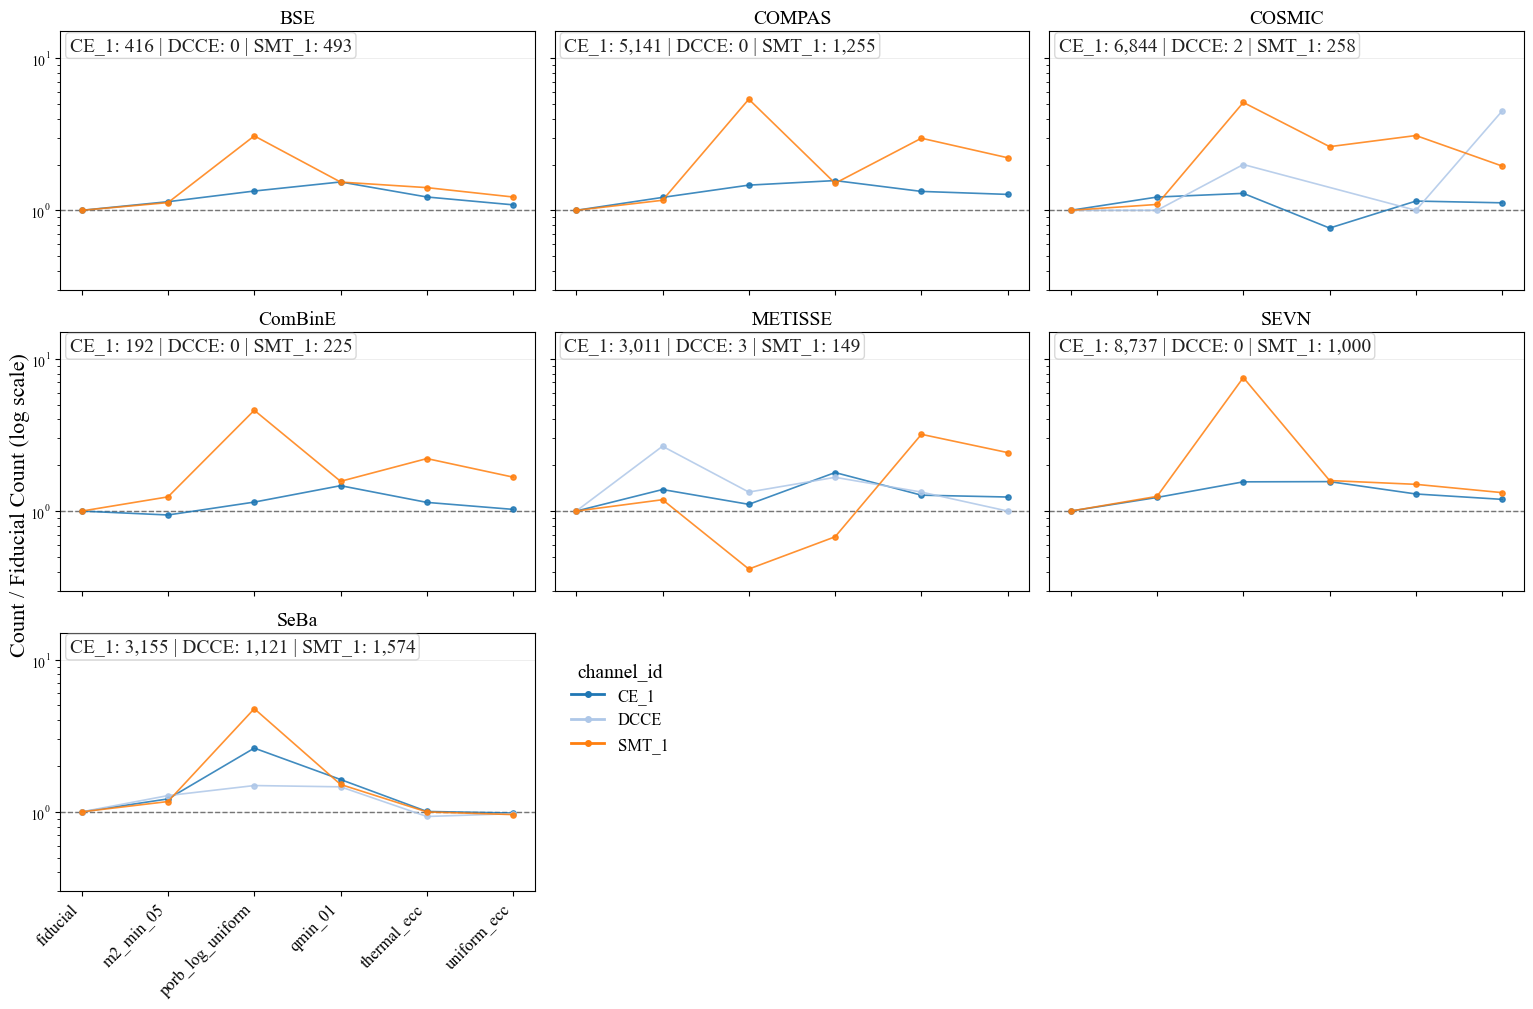

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

# ----------------------------
# Settings
# ----------------------------
phase_to_plot = "LISA_DWD"
ncols = 3
save_fig = True
outname = "channel_relative_ic_panels.pdf"

show_fiducial_text = True
fid_text_fontsize = 14

# ----------------------------
# Prepare data
# ----------------------------
df = channel_counts.copy()

if "count" in df.columns:
    count_col = "count"
else:
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "ID"]
    count_col = numeric_cols[0]

if phase_to_plot is not None and "phase" in df.columns:
    if phase_to_plot in df["phase"].astype(str).unique():
        df = df[df["phase"] == phase_to_plot].copy()

df = df[df["variation"].isin(ic_vars)].copy()
df = df.groupby(["code", "variation", "channel_id"], as_index=False)[count_col].sum()

fid = (
    df[df["variation"] == "fiducial"][["code", "channel_id", count_col]]
    .rename(columns={count_col: "fiducial_count"})
)

plot_df = df.merge(fid, on=["code", "channel_id"], how="left")

# Remove unwanted channel types
for pat in ["merger", "nonRLO", "other"]:
    plot_df = plot_df[~plot_df["channel_id"].astype(str).str.contains(pat, case=False, na=False)].copy()

plot_df["rel"] = np.where(
    (plot_df["fiducial_count"] > 0) & np.isfinite(plot_df["fiducial_count"]),
    plot_df[count_col] / plot_df["fiducial_count"],
    np.nan
)
plot_df = plot_df.dropna(subset=["rel"]).copy()

var_order = [v for v in ic_vars if v in plot_df["variation"].unique()]
code_order = sorted(plot_df["code"].unique().tolist())
chan_order = sorted(plot_df["channel_id"].astype(str).unique().tolist())

plot_df["variation"] = pd.Categorical(plot_df["variation"], categories=var_order, ordered=True)
plot_df["x"] = plot_df["variation"].cat.codes

plot_pos = plot_df[plot_df["rel"] > 0].copy()
if plot_pos.empty:
    raise ValueError("No positive relative values available for log-scale plotting.")

y_min = 0.3
y_max = 15

cmap = plt.get_cmap("tab20")
chan_to_color = {ch: cmap(i % 20) for i, ch in enumerate(chan_order)}

fid_lookup = (
    fid.copy()
    .assign(channel_id=lambda d: d["channel_id"].astype(str))
    .groupby(["code", "channel_id"], as_index=False)["fiducial_count"]
    .sum()
)
for pat in ["merger", "nonRLO", "other"]:
    fid_lookup = fid_lookup[~fid_lookup["channel_id"].str.contains(pat, case=False, na=False)].copy()

# ----------------------------
# Plot
# ----------------------------
n_codes = len(code_order)
nrows = math.ceil(n_codes / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5.2 * ncols, 3.4 * nrows),
    sharex=True, sharey=True
)
axes = np.atleast_1d(axes).ravel()

for i, code in enumerate(code_order):
    ax = axes[i]
    d_code = plot_pos[plot_pos["code"] == code]

    ax.axhline(1.0, color="#666666", lw=1.0, ls="--", zorder=0)

    for ch in chan_order:
        s = d_code[d_code["channel_id"].astype(str) == ch].sort_values("x")
        if s.empty:
            continue
        ax.plot(s["x"].values, s["rel"].values, color=chan_to_color[ch],
                lw=1.2, alpha=0.85, marker="o", markersize=3.8)

    ax.set_title(code, fontsize=14)
    ax.set_yscale("log")
    ax.set_ylim(y_min, y_max)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_xticks(range(len(var_order)))
    ax.set_xticklabels(var_order, rotation=45, ha="right", fontsize=12)

    if show_fiducial_text:
        code_fid = fid_lookup[fid_lookup["code"] == code].sort_values("channel_id")
        if not code_fid.empty:
            chunks = []
            for _, r in code_fid.iterrows():
                ch = r["channel_id"]
                v = r["fiducial_count"]
                if pd.isna(v):
                    vtxt = "nan"
                elif float(v).is_integer():
                    vtxt = f"{int(v):,}"
                else:
                    vtxt = f"{v:,.2f}"
                chunks.append(f"{ch}: {vtxt}")
            ax.text(0.02, 0.98, " | ".join(chunks), transform=ax.transAxes,
                    ha="left", va="top", fontsize=fid_text_fontsize, color="#222222",
                    bbox=dict(facecolor="white", edgecolor="#cccccc", alpha=0.75, boxstyle="round,pad=0.2"),
                    clip_on=True)

for j in range(n_codes, len(axes)):
    axes[j].set_visible(False)

#fig.suptitle("Relative Channel Counts by IC Variation"
#             + (f" ({phase_to_plot})" if phase_to_plot else ""), y=1.02, fontsize=12)
#fig.supxlabel("Variation")
fig.supylabel("Count / Fiducial Count (log scale)", fontsize=16)

legend_handles = [Line2D([0], [0], color=chan_to_color[ch], lw=2, marker="o", markersize=4, label=str(ch))
                  for ch in chan_order]
fig.legend(handles=legend_handles, title="channel_id",
           bbox_to_anchor=(0.37, 0.36), loc="upper left", frameon=False,
           fontsize=12, title_fontsize=14)

plt.tight_layout()
if save_fig:
    plt.savefig(outname, bbox_inches="tight")
plt.show()

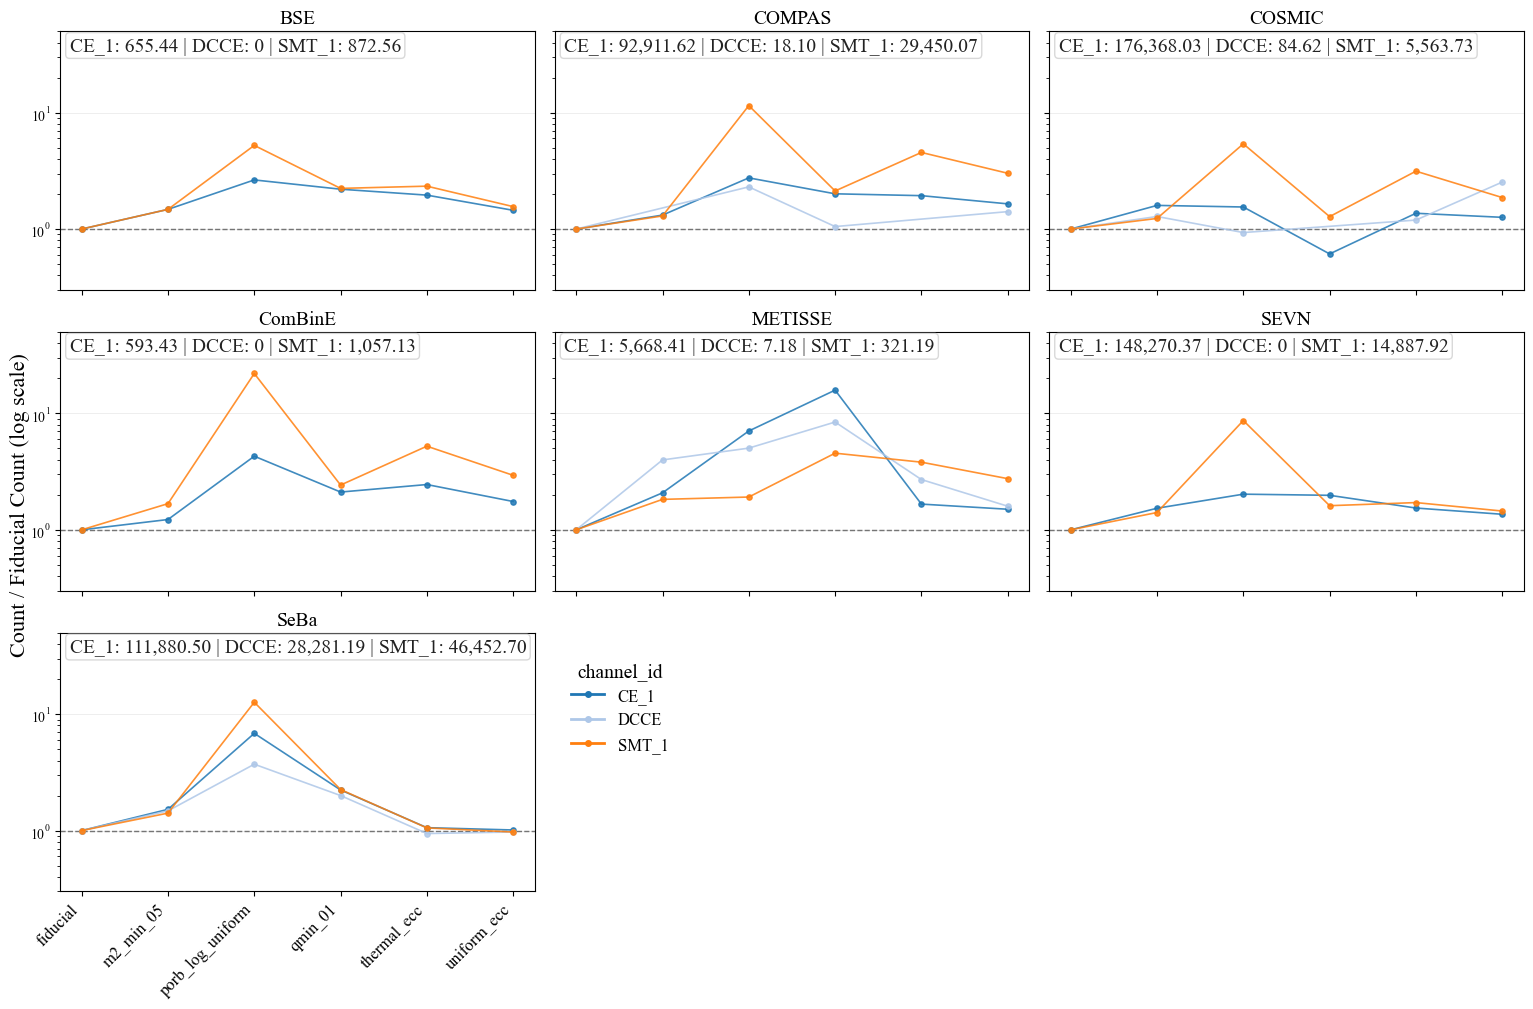

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

# ----------------------------
# Settings
# ----------------------------
phase_to_plot = "Galaxy"
ncols = 3
save_fig = True
outname = "all_DWDs_channel_relative_ic_panels.pdf"

show_fiducial_text = True
fid_text_fontsize = 14

# ----------------------------
# Prepare data
# ----------------------------
df = channel_counts.copy()

if "count" in df.columns:
    count_col = "count"
else:
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "ID"]
    count_col = numeric_cols[0]

if phase_to_plot is not None and "phase" in df.columns:
    if phase_to_plot in df["phase"].astype(str).unique():
        df = df[df["phase"] == phase_to_plot].copy()

df = df[df["variation"].isin(ic_vars)].copy()
df = df.groupby(["code", "variation", "channel_id"], as_index=False)[count_col].sum()

fid = (
    df[df["variation"] == "fiducial"][["code", "channel_id", count_col]]
    .rename(columns={count_col: "fiducial_count"})
)

plot_df = df.merge(fid, on=["code", "channel_id"], how="left")

# Remove unwanted channel types
for pat in ["merger", "nonRLO", "other"]:
    plot_df = plot_df[~plot_df["channel_id"].astype(str).str.contains(pat, case=False, na=False)].copy()

plot_df["rel"] = np.where(
    (plot_df["fiducial_count"] > 0) & np.isfinite(plot_df["fiducial_count"]),
    plot_df[count_col] / plot_df["fiducial_count"],
    np.nan
)
plot_df = plot_df.dropna(subset=["rel"]).copy()

var_order = [v for v in ic_vars if v in plot_df["variation"].unique()]
code_order = sorted(plot_df["code"].unique().tolist())
chan_order = sorted(plot_df["channel_id"].astype(str).unique().tolist())

plot_df["variation"] = pd.Categorical(plot_df["variation"], categories=var_order, ordered=True)
plot_df["x"] = plot_df["variation"].cat.codes

plot_pos = plot_df[plot_df["rel"] > 0].copy()
if plot_pos.empty:
    raise ValueError("No positive relative values available for log-scale plotting.")

y_min = 0.3
y_max = 50

cmap = plt.get_cmap("tab20")
chan_to_color = {ch: cmap(i % 20) for i, ch in enumerate(chan_order)}

fid_lookup = (
    fid.copy()
    .assign(channel_id=lambda d: d["channel_id"].astype(str))
    .groupby(["code", "channel_id"], as_index=False)["fiducial_count"]
    .sum()
)
for pat in ["merger", "nonRLO", "other"]:
    fid_lookup = fid_lookup[~fid_lookup["channel_id"].str.contains(pat, case=False, na=False)].copy()

# ----------------------------
# Plot
# ----------------------------
n_codes = len(code_order)
nrows = math.ceil(n_codes / ncols)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5.2 * ncols, 3.4 * nrows),
    sharex=True, sharey=True
)
axes = np.atleast_1d(axes).ravel()

for i, code in enumerate(code_order):
    ax = axes[i]
    d_code = plot_pos[plot_pos["code"] == code]

    ax.axhline(1.0, color="#666666", lw=1.0, ls="--", zorder=0)

    for ch in chan_order:
        s = d_code[d_code["channel_id"].astype(str) == ch].sort_values("x")
        if s.empty:
            continue
        ax.plot(s["x"].values, s["rel"].values, color=chan_to_color[ch],
                lw=1.2, alpha=0.85, marker="o", markersize=3.8)

    ax.set_title(code, fontsize=14)
    ax.set_yscale("log")
    ax.set_ylim(y_min, y_max)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_xticks(range(len(var_order)))
    ax.set_xticklabels(var_order, rotation=45, ha="right", fontsize=12)

    if show_fiducial_text:
        code_fid = fid_lookup[fid_lookup["code"] == code].sort_values("channel_id")
        if not code_fid.empty:
            chunks = []
            for _, r in code_fid.iterrows():
                ch = r["channel_id"]
                v = r["fiducial_count"]
                if pd.isna(v):
                    vtxt = "nan"
                elif float(v).is_integer():
                    vtxt = f"{int(v):,}"
                else:
                    vtxt = f"{v:,.2f}"
                chunks.append(f"{ch}: {vtxt}")
            ax.text(0.02, 0.98, " | ".join(chunks), transform=ax.transAxes,
                    ha="left", va="top", fontsize=fid_text_fontsize, color="#222222",
                    bbox=dict(facecolor="white", edgecolor="#cccccc", alpha=0.75, boxstyle="round,pad=0.2"),
                    clip_on=True)

for j in range(n_codes, len(axes)):
    axes[j].set_visible(False)

#fig.suptitle("Relative Channel Counts by IC Variation"
#             + (f" ({phase_to_plot})" if phase_to_plot else ""), y=1.02, fontsize=12)
#fig.supxlabel("Variation")
fig.supylabel("Count / Fiducial Count (log scale)", fontsize=16)

legend_handles = [Line2D([0], [0], color=chan_to_color[ch], lw=2, marker="o", markersize=4, label=str(ch))
                  for ch in chan_order]
fig.legend(handles=legend_handles, title="channel_id",
           bbox_to_anchor=(0.37, 0.36), loc="upper left", frameon=False,
           fontsize=12, title_fontsize=14)

plt.tight_layout()
if save_fig:
    plt.savefig(outname, bbox_inches="tight")
plt.show()

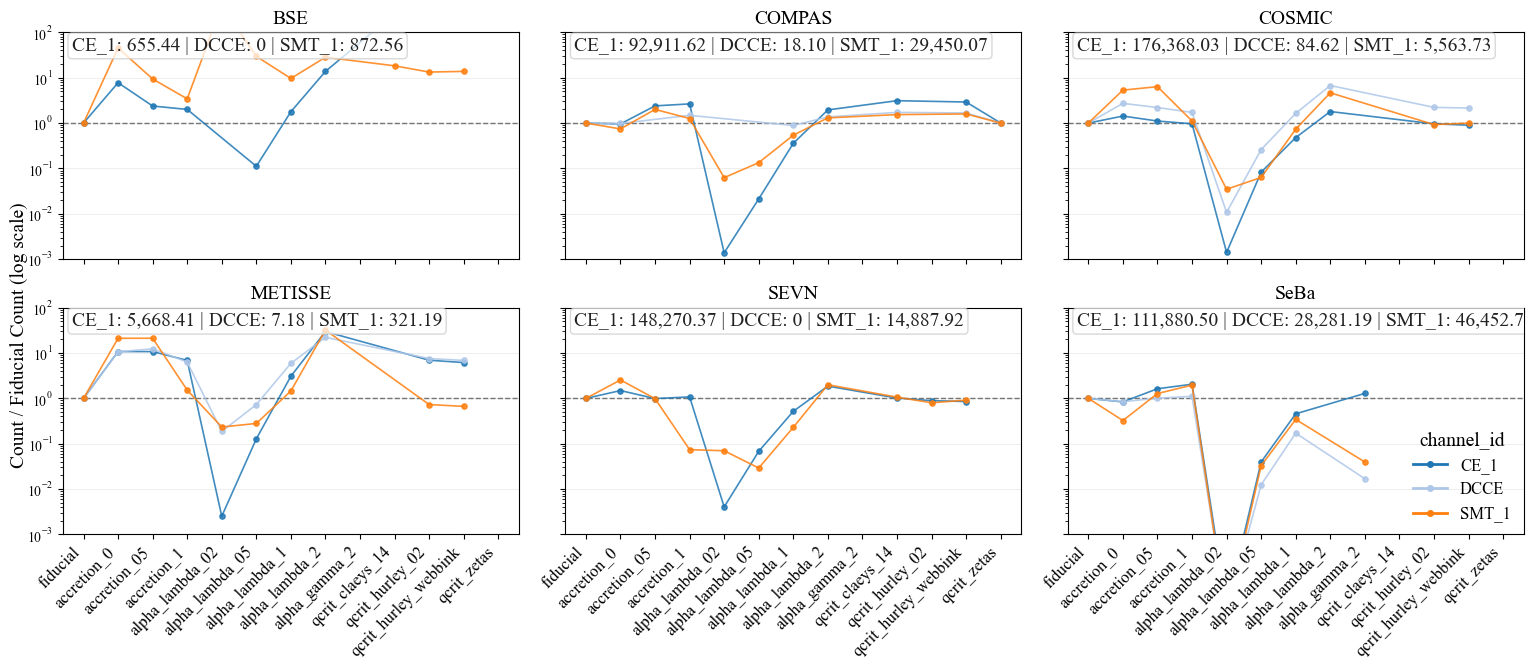

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math

# ----------------------------
# Settings
# ----------------------------
phase_to_plot = "Galaxy"   # set None to include all phases
ncols = 3
save_fig = True
outname = "all_DWDs_channel_relative_mt_panels.pdf"

# Text settings
show_fiducial_text = True
fid_text_fontsize = 14

# ----------------------------
# Prepare data
# ----------------------------
df = channel_counts.copy()

required = {"code", "variation", "channel_id"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if "count" in df.columns:
    count_col = "count"
else:
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "ID"]
    if not numeric_cols:
        raise ValueError("No numeric count column found.")
    count_col = numeric_cols[0]
    print(f"Using '{count_col}' as count column.")

if phase_to_plot is not None and "phase" in df.columns:
    if phase_to_plot in df["phase"].astype(str).unique():
        df = df[df["phase"] == phase_to_plot].copy()
    else:
        print(f"Phase '{phase_to_plot}' not found; using all phases.")

# Keep MT vars only
df = df[df["variation"].isin(mt_vars)].copy()

# Collapse duplicates per code-variation-channel
df = df.groupby(["code", "variation", "channel_id"], as_index=False)[count_col].sum()

# Fiducial baseline per code+channel
fid = (
    df[df["variation"] == "fiducial"][["code", "channel_id", count_col]]
    .rename(columns={count_col: "fiducial_count"})
)

plot_df = df.merge(fid, on=["code", "channel_id"], how="left")
# Remove merger-like channels (case-insensitive)

plot_df = plot_df[
    ~plot_df["channel_id"].astype(str).str.contains("merger", case=False, na=False)
].copy()

plot_df = plot_df[
    ~plot_df["channel_id"].astype(str).str.contains("nonRLO", case=False, na=False)
].copy()

plot_df = plot_df[
    ~plot_df["channel_id"].astype(str).str.contains("other", case=False, na=False)
].copy()


plot_df["rel"] = np.where(
    (plot_df["fiducial_count"] > 0) & np.isfinite(plot_df["fiducial_count"]),
    plot_df[count_col] / plot_df["fiducial_count"],
    np.nan
)
plot_df = plot_df.dropna(subset=["rel"]).copy()

# Remove ComBinE panel
plot_df = plot_df[plot_df["code"] != "ComBinE"].copy()

var_order = [v for v in mt_vars if v in plot_df["variation"].unique()]
code_order = sorted(plot_df["code"].unique().tolist())
chan_order = sorted(plot_df["channel_id"].astype(str).unique().tolist())

plot_df["variation"] = pd.Categorical(plot_df["variation"], categories=var_order, ordered=True)
plot_df["x"] = plot_df["variation"].cat.codes

# Positive-only values for log scale
plot_pos = plot_df[plot_df["rel"] > 0].copy()
if plot_pos.empty:
    raise ValueError("No positive relative values available for log-scale plotting.")

# Global y-limits from data (no clipping)
y_min = 1e-3
y_max = 100

# Channel colors shared across panels
cmap = plt.get_cmap("tab20")
chan_to_color = {ch: cmap(i % 20) for i, ch in enumerate(chan_order)}

# Build fiducial lookup text table per code
fid_lookup = (
    fid.copy()
    .assign(channel_id=lambda d: d["channel_id"].astype(str))
    .groupby(["code", "channel_id"], as_index=False)["fiducial_count"]
    .sum()
)

fid_lookup = fid_lookup[~fid_lookup["channel_id"].str.contains("merger", case=False, na=False)].copy()
fid_lookup = fid_lookup[~fid_lookup["channel_id"].str.contains("nonRLO", case=False, na=False)].copy()
fid_lookup = fid_lookup[~fid_lookup["channel_id"].str.contains("other", case=False, na=False)].copy()
# ----------------------------
# Plot
# ----------------------------
n_codes = len(code_order)
nrows = math.ceil(n_codes / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.2 * ncols, 3.4 * nrows),   # a bit larger so text fits
    sharex=True,
    sharey=True
)
axes = np.atleast_1d(axes).ravel()

for i, code in enumerate(code_order):
    ax = axes[i]
    d_code = plot_pos[plot_pos["code"] == code]

    # Fiducial reference line
    ax.axhline(1.0, color="#666666", lw=1.0, ls="--", zorder=0)

    for ch in chan_order:
        s = d_code[d_code["channel_id"].astype(str) == ch].sort_values("x")
        if s.empty:
            continue

        ax.plot(
            s["x"].values, s["rel"].values,
            color=chan_to_color[ch],
            lw=1.2, alpha=0.85,
            marker="o", markersize=3.8
        )

    ax.set_title(code, fontsize=14)
    ax.set_yscale("log")
    ax.set_ylim(y_min, y_max)
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)

    ax.set_xticks(range(len(var_order)))
    ax.set_xticklabels(var_order, rotation=45, ha="right", fontsize=12)

    # Add fiducial count text line (horizontal)
    if show_fiducial_text:
        code_fid = (
            fid_lookup[fid_lookup["code"] == code]
            .sort_values("channel_id")
        )
        if not code_fid.empty:
            chunks = []
            for _, r in code_fid.iterrows():
                ch = r["channel_id"]
                v = r["fiducial_count"]
                if pd.isna(v):
                    vtxt = "nan"
                elif float(v).is_integer():
                    vtxt = f"{int(v):,}"
                else:
                    vtxt = f"{v:,.2f}"
                chunks.append(f"{ch}: {vtxt}")

            line = " | ".join(chunks)

            ax.text(
                0.02, 0.98,                 # top-left of panel
                line,
                transform=ax.transAxes,
                ha="left", va="top",
                fontsize=fid_text_fontsize,
                color="#222222",
                bbox=dict(facecolor="white", edgecolor="#cccccc", alpha=0.75, boxstyle="round,pad=0.2"),
                clip_on=True
            )

# Hide unused panels
for j in range(n_codes, len(axes)):
    axes[j].set_visible(False)

#fig.suptitle(
#    "Relative Channel Counts by MT Variation"
#    + (f" ({phase_to_plot})" if phase_to_plot is not None else ""),
#    y=1.02, fontsize=12
#)
#fig.supxlabel("Variation")
fig.supylabel("Count / Fiducial Count (log scale)", fontsize=14)

legend_handles = [
    Line2D([0], [0], color=chan_to_color[ch], lw=2, marker="o", markersize=4, label=str(ch))
    for ch in chan_order
]
fig.legend(
    handles=legend_handles,
    title="channel_id",
    bbox_to_anchor=(0.91,0.38),
    loc="upper left",
    frameon=False, fontsize=12, title_fontsize=14
)

plt.tight_layout()
if save_fig:
    plt.savefig(outname, bbox_inches="tight")
plt.show()